In [1]:
import pandas as pd
data = pd.read_csv("Student_scores.csv")
print(data.head(10))

     name  hours  score gender grades class
0   Aarav    NaN   76.0      M      A    9A
1    Riya    5.0   62.0      F      B    9B
2   Kabir   10.0    NaN      M      A   10A
3    Sana    4.0   55.0      F      C    9A
4  Vivaan    7.0   72.0      M      B   10B
5  Ishita    6.0   64.0      F      B    9C
6   Rohan    3.0   48.0      M      D    9B
7   Meera    9.0   90.0      F      A   11A
8  Aditya    2.0   38.0      M      F    9C
9   Kavya   11.0   93.0      F      A   12A


In [2]:
# Inspect columns
print('Columns:', data.columns.tolist())

# 1. Dataset Basic Info
print('\nDataset Info:')
print(data.info())

# Fill missing values in 'score' column
data['score'] = data['score'].fillna(data['score'].mean())
data['hours'] = data['hours'].fillna(data['hours'].mean())

# 2. Completeness: Check for missing values
print('\nDataset Completeness:')
print(data.isnull().sum())

# Dataset Consistency
print('\nDataset Consistency:')
print(data.dtypes)

data


Columns: ['name', 'hours', 'score', 'gender', 'grades', 'class']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    92 non-null     object 
 1   hours   91 non-null     float64
 2   score   91 non-null     float64
 3   gender  92 non-null     object 
 4   grades  92 non-null     object 
 5   class   92 non-null     object 
dtypes: float64(2), object(4)
memory usage: 4.4+ KB
None

Dataset Completeness:
name      0
hours     0
score     0
gender    0
grades    0
class     0
dtype: int64

Dataset Consistency:
name       object
hours     float64
score     float64
gender     object
grades     object
class      object
dtype: object


,name,hours,score,gender,grades,class
0,Aarav,6.494505,76.000000,M,A,9A
1,Riya,5.000000,62.000000,F,B,9B
2,Kabir,10.000000,68.626374,M,A,10A
3,Sana,4.000000,55.000000,F,C,9A
4,Vivaan,7.000000,72.000000,M,B,10B
...,...,...,...,...,...,...
87,Prisha,4.000000,52.000000,F,C,9A
88,Neil,10.000000,88.000000,M,A,12C
89,Rutvi,7.000000,73.000000,F,B,10A
90,Harshit,5.000000,57.000000,M,C,9B


In [3]:
print('\nDataset Describe:')
data.describe()
print('\nDataset Time-Keeping:')
print('\nNo Timestamp')
print('\nDataset Bias')
print(data['gender'].value_counts(normalize=True))
print(data['grades'].value_counts(normalize=True))
data['class'].value_counts(normalize=True)



Dataset Describe:

Dataset Time-Keeping:

No Timestamp

Dataset Bias
gender
F    0.51087
M    0.48913
Name: proportion, dtype: float64
grades
B    0.358696
A    0.326087
C    0.195652
D    0.086957
F    0.032609
Name: proportion, dtype: float64


class
9A     0.141304
10A    0.119565
9B     0.108696
9C     0.108696
10B    0.086957
11A    0.086957
10C    0.076087
12A    0.065217
12B    0.065217
11B    0.054348
12C    0.054348
11C    0.032609
Name: proportion, dtype: float64

In [22]:
categorial = data.select_dtypes(include ='object').columns
numerical = data.select_dtypes(include ='int64').columns

print("Categorial Features:",list(categorial))
print("Numerical Features:",list(numerical))
x = data[["hours"]]
y = data["score"]

Categorial Features: ['name', 'gender', 'grades', 'class']
Numerical Features: []


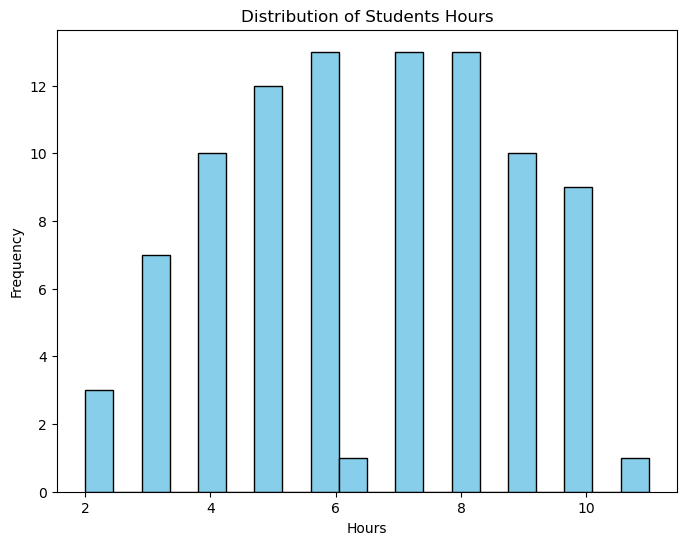

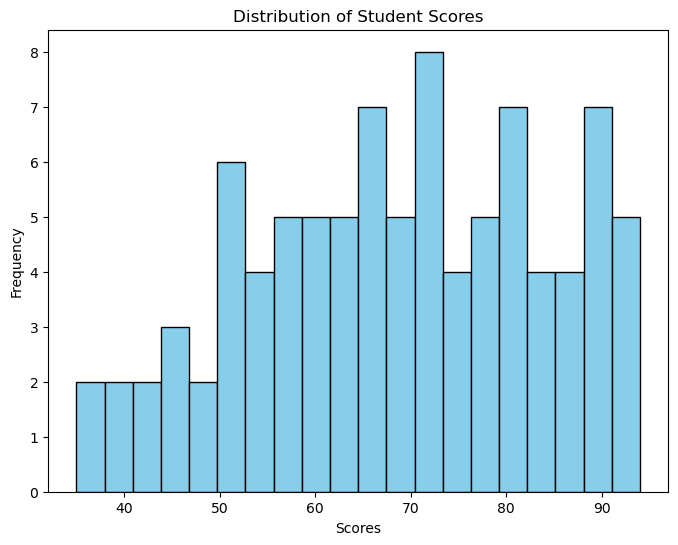

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.hist(x, bins=20,color='skyblue',edgecolor='black')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.title('Distribution of Students Hours')
plt.show()

plt.figure(figsize=(8,6))
plt.hist(y, bins=20, color='skyblue',edgecolor='black')
plt.xlabel('Scores')
plt.ylabel('Frequency')
plt.title('Distribution of Student Scores')
plt.show()


In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42
)

In [7]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

print("Model Coefficient (Slope):",model.coef_[0])
print("Model Intercept:", model.intercept_)

Model Coefficient (Slope): 6.622682199524146
Model Intercept: 25.549537474729576


In [10]:

y_pred = model.predict(x_test)

user_input = int(input("enter your study hours"))
print(model.predict([[user_input]]))

enter your study hours 7


[71.90831287]


C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


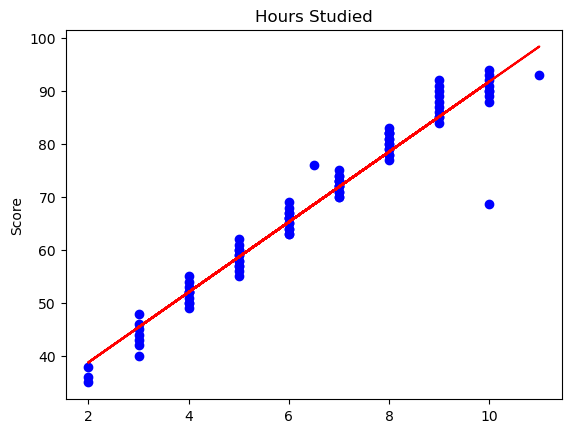

In [11]:
import matplotlib.pyplot as plt
plt.scatter(x,y,color='blue')
plt.plot(x,model.predict(x),color='red')
plt.title("Hours Studied")
plt.ylabel("Score")
plt.show()

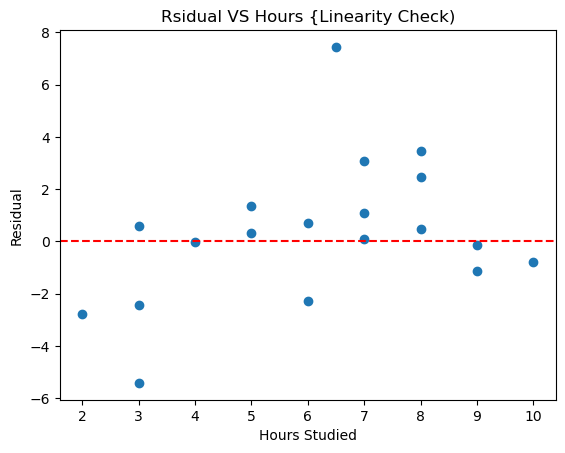

In [18]:
residual = y_test - y_pred
plt.scatter(x_test,residual)
plt.axhline(y=0, color='red' , linestyle='--')
plt.xlabel("Hours Studied")
plt.ylabel("Residual")
plt.title("Rsidual VS Hours {Linearity Check)")
plt.show()

In [19]:
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R^2 : {r2:.3f}")


MSE : 7.23
RMSE : 2.69
R^2 : 0.973
